Below are code cells corresponding to the figures of the IJCAR 2026 short paper submission, plus additional details.

# Figure 1

Parsing a fuzzy sort taxonomy

In [1]:
from fosf.parsers import parse_taxonomy
ftax_str = """
# Fuzzy subsumption declarations
director < person.
slasher < thriller (0.5), horror.
thriller, horror < movie.
# Fuzzy instance declarations
{h, 0.7/p} < slasher.
{p} < horror, thriller.
"""
ftax = parse_taxonomy(ftax_str)

In [2]:
print(type(ftax))

<class 'fosf.syntax.taxonomy.FuzzySortTaxonomy'>


Drawing the fuzzy taxonomy

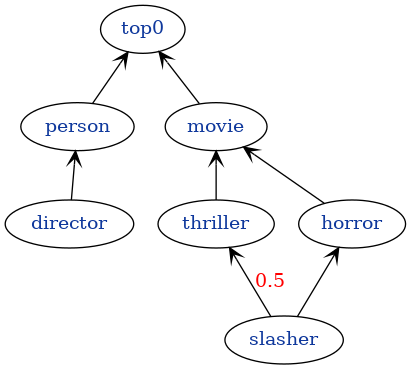

In [3]:
from fosf.utils.draw import notebook_display as display
display(ftax, drop="bot", instances=False)

Accessing instances

In [4]:
from fosf.syntax import Sort
ftax.instances["p"][Sort("slasher")]

0.7

Computing GLBs

In [5]:
ftax.glb("thriller", "horror")

Sort('slasher')

Checking sort subsumption

In [6]:
ftax.is_subsort("slasher", "thriller")

True

Computing subsumption degrees

In [7]:
ftax.degree("slasher", "thriller")

0.5

In [8]:
ftax.degree("slasher", "movie")

1.0

Computing membership degrees of each instance with respect to a few sorts:

In [9]:
for movie in ["h", "p"]:
    print(movie)
    for genre in ["slasher", "horror", "thriller", "movie"]:
        degree = ftax.membership_degree(movie, genre)
        print(f"{genre}({movie}) = {degree}")

h
slasher(h) = 1.0
horror(h) = 1.0
thriller(h) = 0.5
movie(h) = 1.0
p
slasher(p) = 0.7
horror(p) = 1.0
thriller(p) = 1.0
movie(p) = 1.0


# Figure 2

Parsing an OSF term and converting it to an OSF clause

In [10]:
from fosf.parsers import parse_term
term_str = "X0:movie(directed_by -> X1:person, written_by -> X1)"
term = parse_term(term_str)
print(term.to_clause())

X0 : movie  &  X0.directed_by = X1  &  X0.written_by = X1  &  X1 : person.


We can pretty-print the OSF term

In [11]:
term.pretty_print()

X0 : movie(
    directed_by -> X1 : person
    written_by -> X1
)


And also draw it

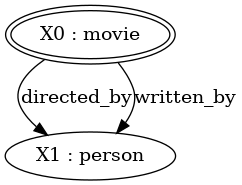

In [12]:
display(term)

# Figure 4

Unifying two OSF terms

In [13]:
from fosf.reasoning import unify_terms
t1 = parse_term("horror(directed_by -> director)")
t2 = parse_term("thriller(directed_by -> X:person , written_by -> X)")
unif, deg = unify_terms([t1, t2], ftax, return_degree=True)
print(unif, deg)

X0 : slasher(directed_by -> X1 : director, written_by -> X1) 0.5


We can draw the unification, including the tag mappings from `t1` and `t2` to the unifier.

In [14]:
from fosf.utils.draw import unification_to_agraph

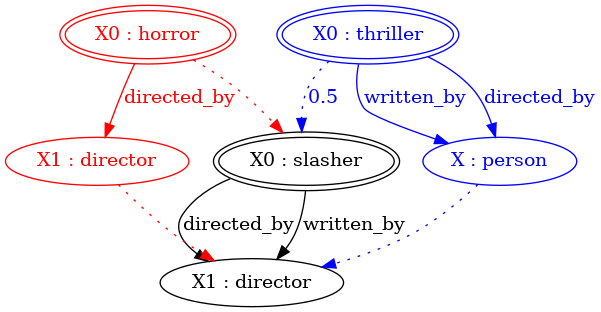

In [15]:
display(unification_to_agraph([t1, t2], ftax))

Checking OSF term subsumption, and computing the subsumption degree

In [16]:
from fosf.syntax import NormalTerm
t1 = parse_term("thriller(directed_by -> person)", create_using=NormalTerm)
t2 = parse_term("slasher(directed_by -> director(spouse -> person))", create_using=NormalTerm)
unif, deg = unify_terms([t1, t2], ftax, return_degree=True)
print(unif)

X0 : slasher(directed_by -> X1 : director(spouse -> X4 : person))


The unifier is equivalent to `t2`, i.e., `t2` is subsumed by `t1`, with degree `deg`.

In [17]:
unif.equivalent_to(t2), deg

(True, 0.5)

# Figure 5

Parsing an OSF theory and ensuring its order-consistency.

In [18]:
from fosf.parsers import parse_theory
from fosf.reasoning import normalize_term
theory_str = ftax_str + """
person := Yperson:person(spouse->Y0:person(spouse->Yperson),
                         fav_movie->Y1:thriller).
movie  := Ymovie:movie(directed_by->Y2:director).
"""
theory = parse_theory(theory_str, ensure_closed=True)

Although `slasher` is not explicitly defined, it inherits the constraints from `movie`:

In [19]:
print(theory['slasher'])

Yslasher : slasher(directed_by -> Y7 : director)


Parsing an OSF term and normalizing it according to the theory:

In [20]:
t_str = "X0:person(spouse->X1(fav_movie->slasher(directed_by->X0)))"
t = parse_term(t_str)
nt, d = normalize_term(t, ftax, theory, return_degree=True)
print(nt)

X0 : director(spouse -> X1 : person(fav_movie -> X2 : slasher(directed_by -> X0), spouse -> X0))


In [21]:
nt.pretty_print()

X0 : director(
    spouse -> X1 : person(
        fav_movie -> X2 : slasher(
            directed_by -> X0
        )
        spouse -> X0
    )
)


The satisfaction degree of `nt` with respect to the OSF theory:

In [22]:
print(d)

0.5


Additional theory normalization example in the body of the paper:

In [23]:
theory_str = """
bot < s0, s1.
s0, s1 < top.
s0 := Ys0:s0(f0 -> Y0:s0, f1 -> Y1:s1).
s1 := Ys1:s1.
"""
theory = parse_theory(theory_str)
t_str = "X:s0(f0 -> X0:top(f1 -> X1:top))"
t = parse_term(t_str)
t.pretty_print()

X : s0(
    f0 -> X0 : top(
        f1 -> X1 : top
    )
)


According to the theory, `X0` must be of sort `s0`, and `X1` of sort `s1`.

In [24]:
nt = normalize_term(t, theory.taxonomy, theory)
nt.pretty_print()

X : s0(
    f0 -> X0 : s0(
        f1 -> X1 : s1
    )
)
